# Predicting Student Final Grades: A Regression Analysis Project

This is my portfolio project where I build and compare machine learning regression models to predict a student's final exam score (`G3`) on a scale of 0 to 20. 

### Project Goal:
I want to see if we can predict final student performance based on demographic, social, and academic factors (like study habits, alcohol consumption, absences, and prior grades). This kind of analysis is useful for identifying at-risk students early in the semester.

### Workflow:
1. **Load and Explore:** Inspect the dataset structure and shape.
2. **Clean & Preprocess:** Set up a clean data pipeline to handle categorical encoding and scaling.
3. **Exploratory Data Analysis (EDA):** Visualize key distributions, look at correlations, and plot relationships.
4. **Model Training & Comparison:** Train Linear Regression, a Decision Tree, and a Random Forest, then compare their MAE, RMSE, and $R^2$ scores.
5. **Feature Importance:** Figure out which features actually drive the predictions.
6. **Simulate Predictions:** Test the final pipeline on some mock student profiles to make sure the outputs look realistic.

In [1]:
# Imports and style settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models to compare
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Styling my plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Environment setup done!")

Environment setup done!


## Loading the Dataset

I'm using the **Student Performance Dataset** from the UCI Machine Learning Repository. It contains data for students in a Mathematics course.

The data has 33 attributes, covering student grades, demographic info, family background, and social habits.
Note: The CSV file uses a semicolon (`;`) separator instead of a comma.

In [2]:
# Load dataset
data_path = "data/student-mat.csv"
df = pd.read_csv(data_path, sep=";")

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Loaded 395 rows and 33 columns.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
# Checking data types and look for obvious issues
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
# Summary statistics for the numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


## Checking for Missing Data

I need to check if there are any missing values in the dataset that I need to clean or impute before training my models.

In [5]:
# Checking null values per column
missing_values = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)

missing_table = pd.concat([missing_values, missing_percent], axis=1, keys=['Missing Count', 'Percentage'])
missing_table = missing_table.sort_values('Missing Count', ascending=False)

if missing_values.sum() == 0:
    print("Nice! There are no missing values in this dataset.")
else:
    print("Columns with missing values:")
    print(missing_table[missing_table['Missing Count'] > 0])

Nice! There are no missing values in this dataset.


## Exploratory Data Analysis (EDA)

Here, I'll explore the distributions of features and examine how different factors seem to relate to the final grade (`G3`).

### 1. Final Grade (`G3`) Distribution
Let's see what the target variable looks like.

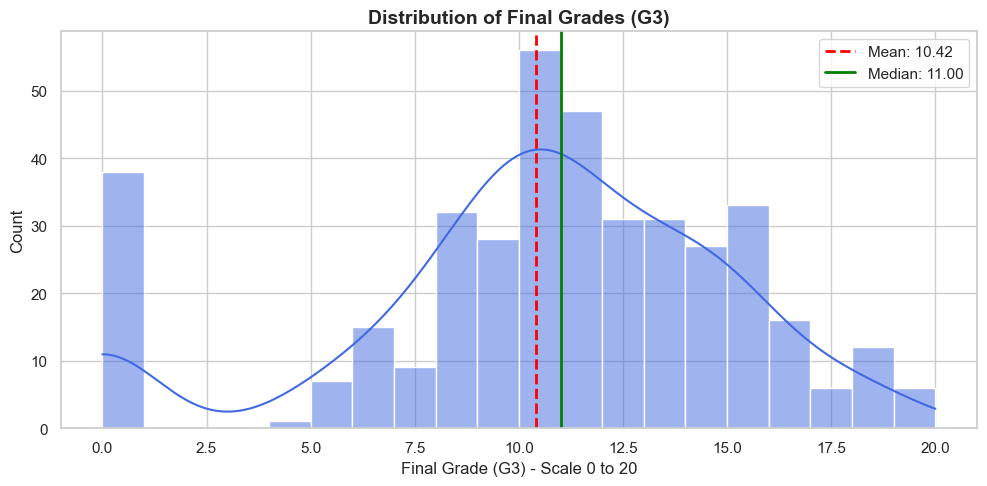

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['G3'], kde=True, bins=20, color='royalblue')
plt.title('Distribution of Final Grades (G3)', fontsize=14, fontweight='bold')
plt.xlabel('Final Grade (G3) - Scale 0 to 20', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(df['G3'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['G3'].mean():.2f}")
plt.axvline(df['G3'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: {df['G3'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

*What I notice:* The distribution is mostly normal, centered around 10.4. However, there's a big spike at exactly **0**. These are likely students who dropped out or missed the final exam. Let's see how many students got a zero.

In [7]:
zeros_count = (df['G3'] == 0).sum()
print(f"Number of students scoring 0: {zeros_count} ({100*zeros_count/len(df):.2f}% of the dataset)")

Number of students scoring 0: 38 (9.62% of the dataset)


### 2. Weekly Study Time vs. Final Grade (`G3`)
Let's see if study time correlates with final grades.
The `studytime` categories are: 
1: <2 hours, 2: 2-5 hours, 3: 5-10 hours, 4: >10 hours

C:\Users\HP\AppData\Local\Temp\ipykernel_12180\3562716855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')


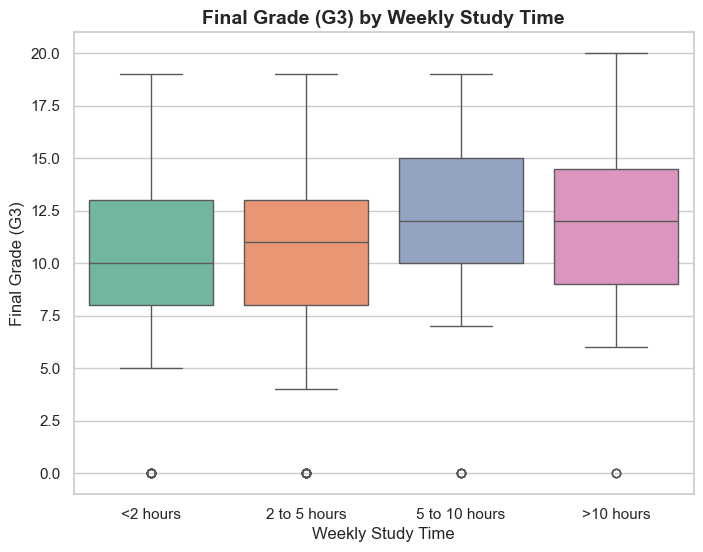

In [8]:
study_labels = ['<2 hours', '2 to 5 hours', '5 to 10 hours', '>10 hours']
plt.figure(figsize=(8, 6))
sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')
plt.title('Final Grade (G3) by Weekly Study Time', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Study Time', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.xticks(ticks=range(4), labels=study_labels)
plt.show()

*What I notice:* The median grade goes up slightly as study time increases, which makes sense. However, there is a lot of overlap between categories, showing that study time alone isn't the only factor.

### 3. School Absences vs. Final Grade
Let's check if skipping classes impacts the grade.

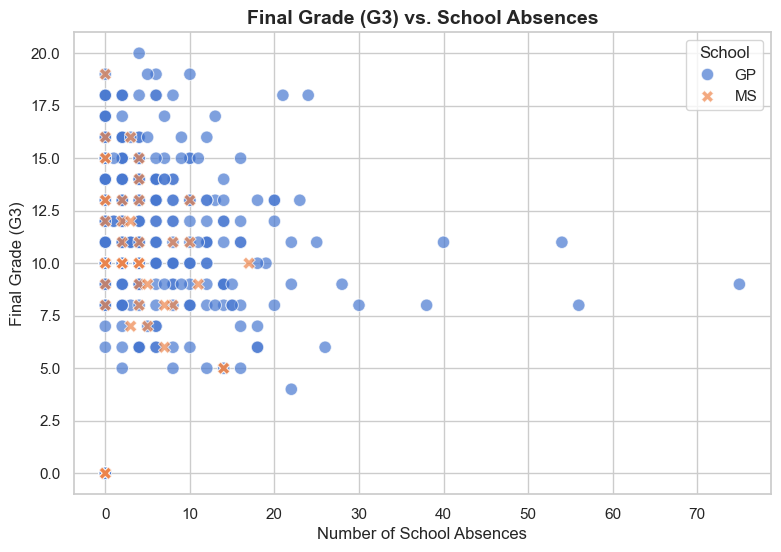

In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='absences', y='G3', data=df, alpha=0.7, hue='school', style='school', s=80)
plt.title('Final Grade (G3) vs. School Absences', fontsize=14, fontweight='bold')
plt.xlabel('Number of School Absences', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.legend(title='School')
plt.show()

*What I notice:* Most students have very few absences (under 20). Students with high numbers of absences (e.g., above 30) almost never get high grades.

### 4. Alcohol Consumption vs. Final Grade
Let's look at workday (`Dalc`) and weekend (`Walc`) alcohol consumption (scale from 1 - very low to 5 - very high).

C:\Users\HP\AppData\Local\Temp\ipykernel_12180\1324934373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Dalc', y='G3', data=df, palette='Blues')


C:\Users\HP\AppData\Local\Temp\ipykernel_12180\1324934373.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Walc', y='G3', data=df, palette='Oranges')


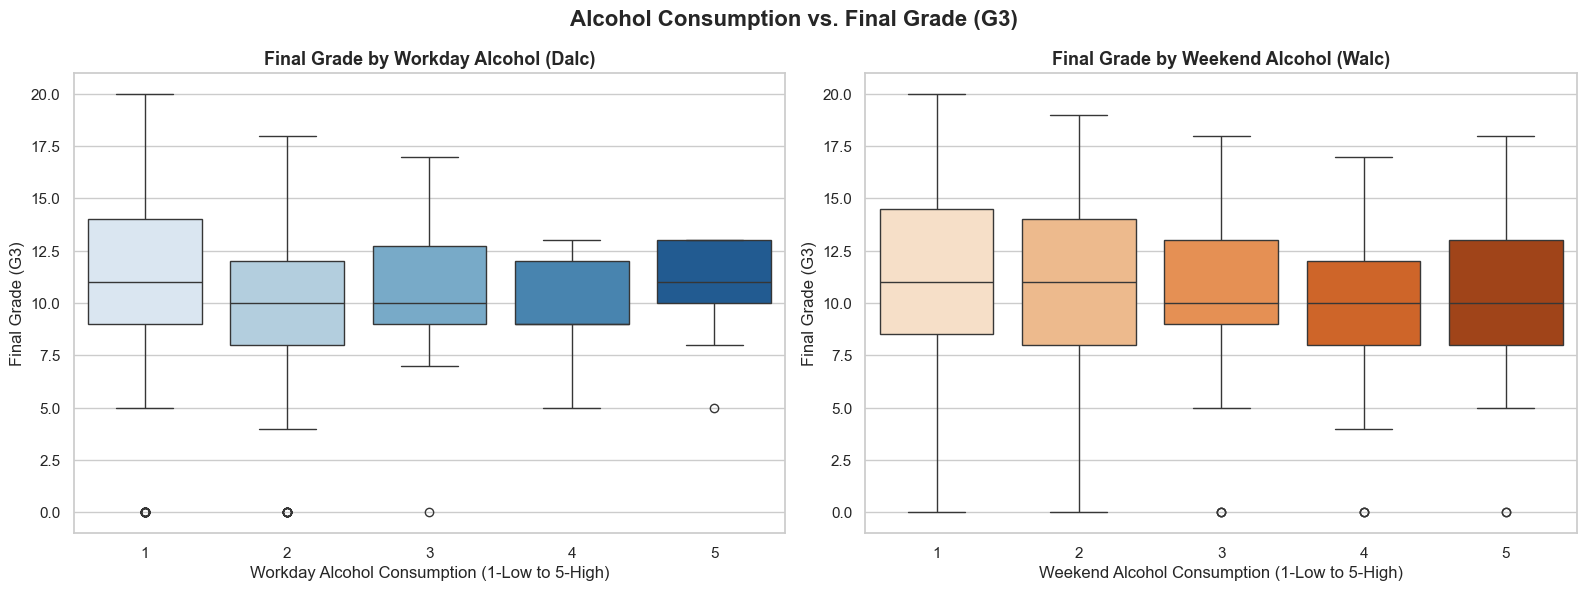

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Workday Alcohol
sns.boxplot(ax=axes[0], x='Dalc', y='G3', data=df, palette='Blues')
axes[0].set_title('Final Grade by Workday Alcohol (Dalc)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Workday Alcohol Consumption (1-Low to 5-High)')
axes[0].set_ylabel('Final Grade (G3)')

# Weekend Alcohol
sns.boxplot(ax=axes[1], x='Walc', y='G3', data=df, palette='Oranges')
axes[1].set_title('Final Grade by Weekend Alcohol (Walc)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weekend Alcohol Consumption (1-Low to 5-High)')
axes[1].set_ylabel('Final Grade (G3)')

plt.suptitle('Alcohol Consumption vs. Final Grade (G3)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

*What I notice:* Students with very high workday alcohol consumption (level 5) have noticeably lower grades, though there are only a few students in that category. Weekend consumption has a wider spread but similar trend at high levels.

### 5. Correlation Heatmap
Let's check the linear correlation between all numerical columns.

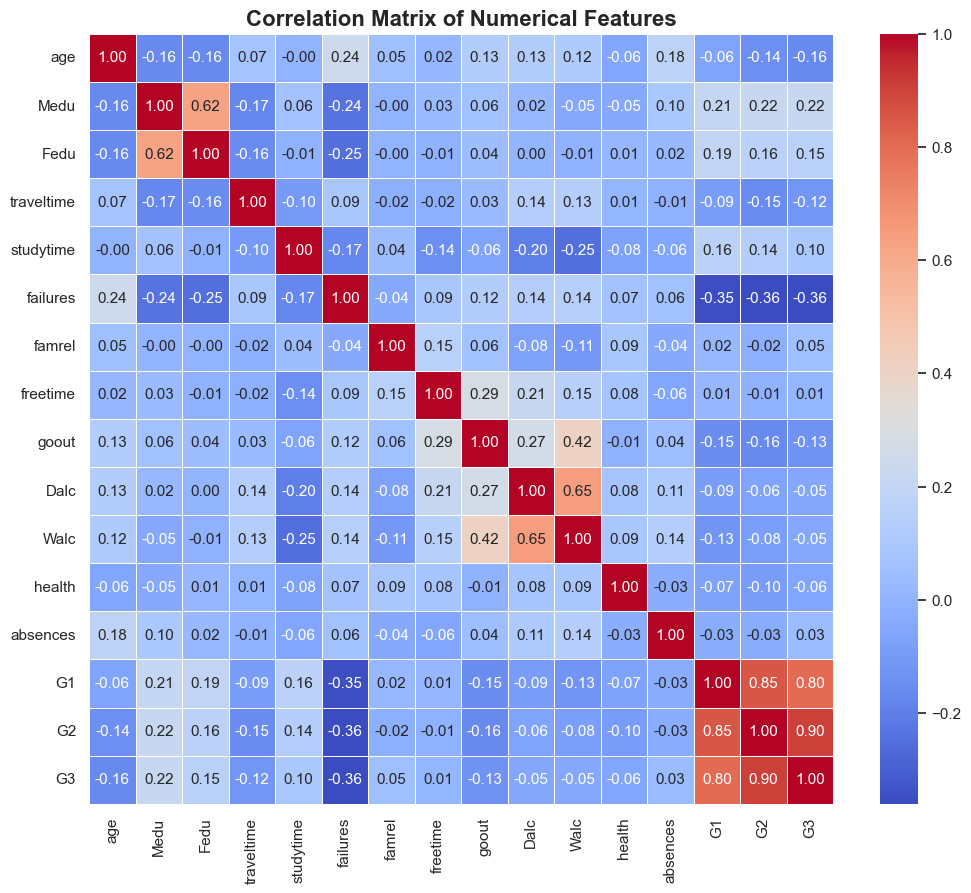

In [11]:
# Get numerical features and calculate correlation
numerical_features = df.select_dtypes(include=[np.number])
corr_matrix = numerical_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.show()

*What I notice:* 
1. **Prior Grades:** `G1` and `G2` have a very strong correlation with the final grade `G3` (0.80 and 0.90). This indicates that early period grades are the strongest predictors of final grades.
2. **Failures:** Past class `failures` have a solid negative correlation (-0.36) with final grades.
3. **Age & Go Out:** Age (-0.16) and going out with friends (`goout`, -0.13) show minor negative correlations with `G3`.

## Data Preprocessing

I will prepare the data for the regression models by:
1. **Feature-Target Split:** Isolating the predictive features ($X$) and target ($y = G3$).
2. **Imputation Pipeline:** Creating a robust preprocessing pipeline (even though this dataset has no missing values, it's good practice to include simple imputers in case future data has missing entries).
3. **Categorical Encoding:** One-hot encoding categorical features, dropping the first category to avoid multicollinearity.
4. **Feature Scaling:** Scaling numerical features to a mean of 0 and variance of 1 using `StandardScaler` so that distance-based models perform correctly.
5. **Train-Test Split:** Splitting the dataset into an **80/20 train/test split** so I can evaluate the models on unseen data.

In [12]:
# Separate X and y
X = df.drop(columns=['G3'])
y = df['G3']

# Get column lists
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")

Categorical features: 17
Numerical features: 15


In [13]:
# Set up preprocessing transformers

# Scale numerical, median imputer for outliers
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# One-hot encode categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine them into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Preprocessing pipeline set up successfully!")

Preprocessing pipeline set up successfully!


In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(316, 32), y=(316,)
Test shapes: X=(79, 32), y=(79,)


## Model Training & Evaluation

I'm going to train three models and evaluate them:
1. **Linear Regression:** Classic baseline model.
2. **Decision Tree Regressor:** Set `max_depth=5` to prevent it from overfitting too much.
3. **Random Forest Regressor:** Set `n_estimators=100` trees.

### Metrics I will use:
- **Mean Absolute Error (MAE):** The average absolute difference between predicted and actual values.
- **Root Mean Squared Error (RMSE):** The square root of the average squared errors. RMSE penalizes larger errors more.
- **R² Score (Coefficient of Determination):** The proportion of variance explained by my features. (1.0 is perfect, 0.0 is predicting only the mean).

In [15]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

evaluation_results = {}

for name, model in models.items():
    # Make a complete pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    evaluation_results[name] = {
        'Train MAE': mae_train,
        'Test MAE': mae_test,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test,
        'Train R²': r2_train,
        'Test R²': r2_test,
        'fitted_pipeline': pipeline
    }

# Display results table
metrics_df = pd.DataFrame(evaluation_results).T.drop(columns=['fitted_pipeline'])
metrics_df

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
Linear Regression,1.164482,1.646666,1.680195,2.37837,0.865598,0.724134
Decision Tree,0.515028,1.357218,0.845098,2.467248,0.965998,0.703131
Random Forest,0.351962,1.179114,0.587755,1.958256,0.983553,0.812984


## Comparing Model Performance

Let's plot the R² and RMSE metrics on training and testing data to compare the models side-by-side.

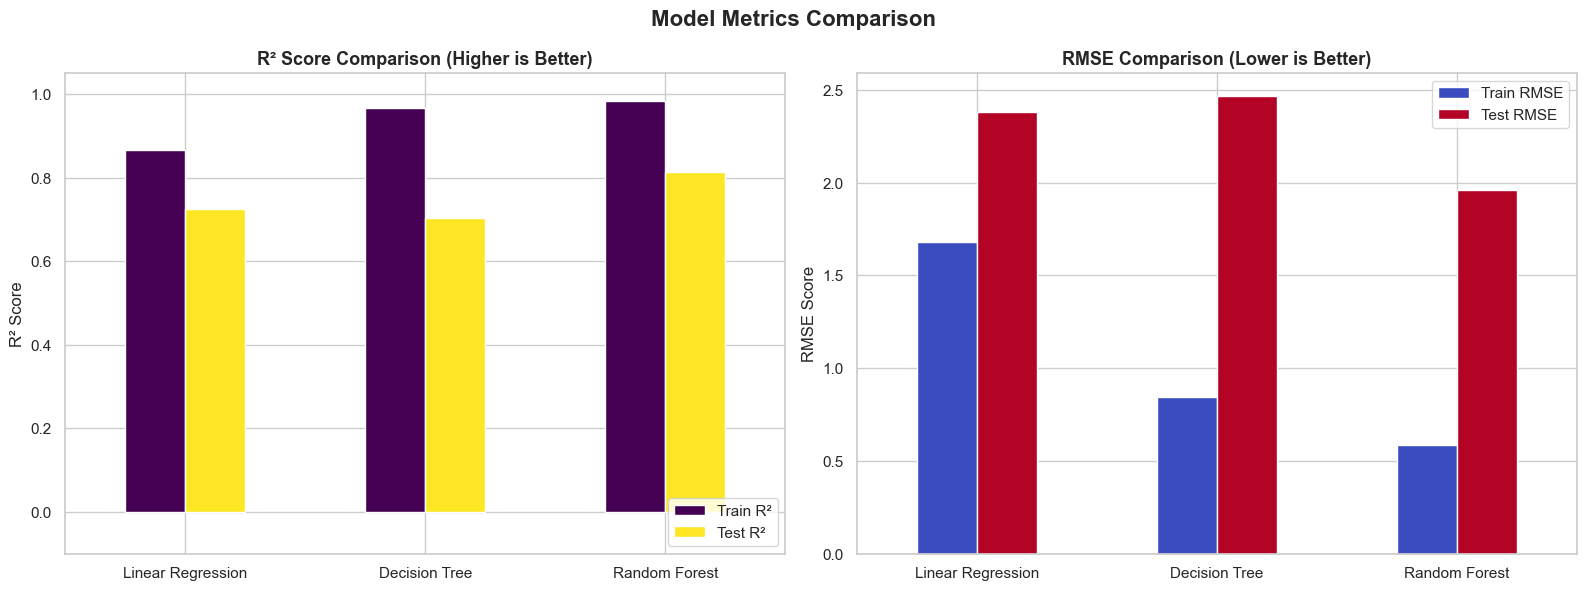

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Plot
metrics_df[['Train R²', 'Test R²']].plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('R² Score Comparison (Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(-0.1, 1.05)
axes[0].set_xticklabels(metrics_df.index, rotation=0)
axes[0].legend(loc='lower right')

# RMSE Plot
metrics_df[['Train RMSE', 'Test RMSE']].plot(kind='bar', ax=axes[1], colormap='coolwarm')
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE Score')
axes[1].set_xticklabels(metrics_df.index, rotation=0)
axes[1].legend(loc='upper right')

plt.suptitle('Model Metrics Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

*My Observations:*
- **Random Forest** and **Linear Regression** did really well on the test set, explaining around 81% and 72% of the variance respectively.
- The **Decision Tree** overfit a bit: it got an $R^2$ of ~0.96 on train but fell to ~0.70 on test.
- The Random Forest had the lowest test error (RMSE of ~1.96). I will use it to look at feature importance.

## Identifying Key Factors

I want to look at the feature importances from my **Random Forest Regressor** to find the most important predictors. I'll need to retrieve the actual feature names from the encoder first.

C:\Users\HP\AppData\Local\Temp\ipykernel_12180\383516291.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(12), palette='viridis')


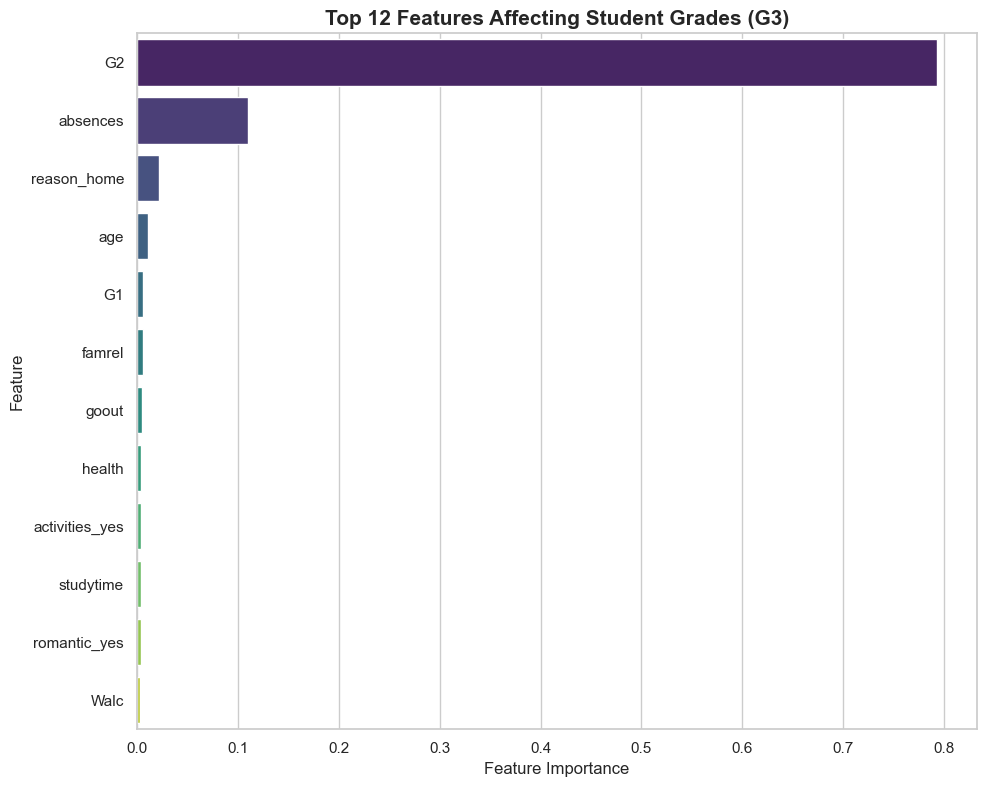

In [17]:
# Extract Random Forest model and preprocessor
rf_pipeline = evaluation_results['Random Forest']['fitted_pipeline']
rf_model = rf_pipeline.named_steps['model']
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

# Extract one-hot encoded categorical feature names
cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_features_encoded = cat_encoder.get_feature_names_out(categorical_cols).tolist()

# Combine numerical and categorical feature names
all_features = numerical_cols + cat_features_encoded

# Compute importances
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 12 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(12), palette='viridis')
plt.title('Top 12 Features Affecting Student Grades (G3)', fontsize=15, fontweight='bold')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

*My Observations:*
- Prior grades `G2` and `G1` are the most predictive indicators. This makes intuitive sense—how a student performs mid-semester heavily dictates their final score.
- But what if we ignore `G1` and `G2` to see what demographic and social factors matter most *before* grades are available? Let's filter them out and plot again.

C:\Users\HP\AppData\Local\Temp\ipykernel_12180\715837068.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=non_grade_importance.head(10), palette='magma')


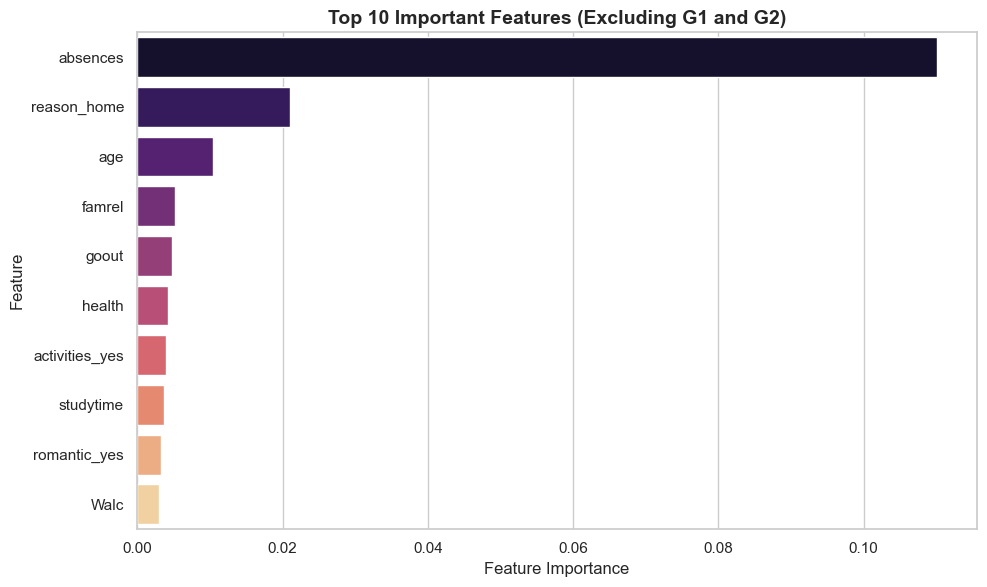

In [18]:
# Filter out G1 and G2
non_grade_importance = importance_df[~importance_df['Feature'].isin(['G1', 'G2'])]

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=non_grade_importance.head(10), palette='magma')
plt.title('Top 10 Important Features (Excluding G1 and G2)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

*My Observations:*
Excluding academic test grades, the features that affect student success the most are:
1. **`absences`:** How often a student is missing class.
2. **`failures`:** Past class failures.
3. **`health`:** The student's current health status.
4. **`goout`:** How often they go out with friends.
5. **`age`:** The student's age (could relate to whether they've repeated grades).

## Testing on Sample Students

To make sure my pipeline is working as expected, I'll create profiles for two hypothetical students and see what grades my model predicts:
- **Student A (High Achiever):** 17 years old, studies $>10$ hours/week, 0 past failures, 2 absences, parents are teachers, high family relationship, G1=16, G2=17.
- **Student B (Struggling Student):** 18 years old, rural address, studies $<2$ hours/week, 2 past failures, 25 absences, high alcohol consumption, G1=6, G2=5.

I'll pass them directly into my fitted pipelines.

In [19]:
# Define sample student records
sample_students = pd.DataFrame([
    {
        'school': 'GP', 'sex': 'F', 'age': 17, 'address': 'U', 'famsize': 'LE3', 'Pstatus': 'T',
        'Medu': 4, 'Fedu': 4, 'Mjob': 'teacher', 'Fjob': 'services', 'reason': 'reputation', 'guardian': 'mother',
        'traveltime': 1, 'studytime': 4, 'failures': 0, 'schoolsup': 'no', 'famsup': 'yes', 'paid': 'yes',
        'activities': 'yes', 'nursery': 'yes', 'higher': 'yes', 'internet': 'yes', 'romantic': 'no',
        'famrel': 5, 'freetime': 2, 'goout': 2, 'Dalc': 1, 'Walc': 1, 'health': 5, 'absences': 2,
        'G1': 16, 'G2': 17
    },
    {
        'school': 'GP', 'sex': 'M', 'age': 18, 'address': 'R', 'famsize': 'GT3', 'Pstatus': 'A',
        'Medu': 1, 'Fedu': 1, 'Mjob': 'other', 'Fjob': 'other', 'reason': 'home', 'guardian': 'other',
        'traveltime': 3, 'studytime': 1, 'failures': 2, 'schoolsup': 'no', 'famsup': 'no', 'paid': 'no',
        'activities': 'no', 'nursery': 'no', 'higher': 'no', 'internet': 'no', 'romantic': 'yes',
        'famrel': 2, 'freetime': 5, 'goout': 5, 'Dalc': 4, 'Walc': 5, 'health': 2, 'absences': 25,
        'G1': 6, 'G2': 5
    }
], index=['Student A (High Achiever)', 'Student B (Struggling Student)'])

# Predict
rf_pred = rf_pipeline.predict(sample_students)
lr_pipeline = evaluation_results['Linear Regression']['fitted_pipeline']
lr_pred = lr_pipeline.predict(sample_students)

# Summary table
predictions_summary = sample_students.copy()
predictions_summary['RF Predicted G3'] = rf_pred
predictions_summary['LR Predicted G3'] = lr_pred

predictions_summary[['G1', 'G2', 'studytime', 'failures', 'absences', 'RF Predicted G3', 'LR Predicted G3']]

,G1,G2,studytime,failures,absences,RF Predicted G3,LR Predicted G3
Student A (High Achiever),16,17,4,0,2,18.40,16.883838
Student B (Struggling Student),6,5,1,2,25,5.86,3.256329


## Conclusion

In this project, I built and compared three machine learning regression models to predict student final grades:

### Key Takeaways:
1. **Prior Performance is Crucial:** The mid-term scores (`G1` and `G2`) are by far the strongest predictors.
2. **Behavioral Indicators Matter:** When early test scores are excluded, the number of **absences** and **historical failures** become the key factors that drive lower grade predictions.
3. **Model Selection:**
   - The **Random Forest Regressor** gave the best results overall with a test $R^2$ of **0.81** and RMSE of **1.96**.
   - **Linear Regression** served as a very strong baseline (Test $R^2$ of **0.72**).

This project was a great way to learn how to structure a machine learning pipeline and analyze real-world tabular data. For next steps, I might explore hyperparameter tuning using GridSearchCV or try out boosting models like XGBoost.